# Astropy

Info on: https://docs.astropy.org/en/stable/

## Units

In [23]:
# Conversion of units:

import astropy.units as u

length = 100*u.meter
print(f"Distance in:\nMeter: {length}\nKilometer: {length.to(u.kilometer)}")

Distance in:
Meter: 100.0 m
Kilometer: 0.1 km


In [24]:
# Multiplication of units:
area = 100*u.meter * 100*u.meter
print(f"Area in:\nmeter: {length}\nKm**2: {area.to(u.kilometer**2)}")

Area in:
meter: 100.0 m
Km**2: 0.01 km2


In [25]:
meter_second = 1* u.meter / u.second
kilometer_second = 1* u.kilometer / u.second

speed_of_light = 299792458 * meter_second

for new_units in [meter_second, kilometer_second]:
    print(f"The speed of light is: {speed_of_light.to(new_units)}")


The speed of light is: 299792458.0 m / s
The speed of light is: 299792.458 km / s


In [26]:
# Division of units with same dimensions results in no units: 
print((2*meter_second) / (4*meter_second))

0.5


In [27]:
# Converting back to floats:

my_data = 1*meter_second
print(my_data.value)
print(my_data.to(kilometer_second).value)


1.0
0.001


# Fits files

The fits format is a widely used one in astrophysics. The data from the majority of the instruments is stored in those files and, consequently, it is important to understand how to use them

Documentation: https://docs.astropy.org/en/stable/io/fits/

In [28]:
# Search for the fits file on the current directory
from pathlib import Path
from astropy.io import fits 

data_path = Path(".").absolute()
s2d_file = list(data_path.glob("resources/r*fits"))[0]


In [29]:
with fits.open(s2d_file) as hdu:
    print(hdu.info())

Filename: /home/amiguel/content/content/Classes/2024/Análise de Dados em Física e Astronomia/resources/r.ESPRE.2019-07-24T00:09:54.984_S2D_BLAZE_A.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU    1518   ()      
  1  SCIDATA       1 ImageHDU        10   (9111, 170)   float32   
  2  ERRDATA       1 ImageHDU        10   (9111, 170)   float32   
  3  QUALDATA      1 ImageHDU        12   (9111, 170)   int16 (rescales to uint16)   
  4  WAVEDATA_VAC_BARY    1 ImageHDU        10   (9111, 170)   float64   
  5  WAVEDATA_AIR_BARY    1 ImageHDU        10   (9111, 170)   float64   
  6  DLLDATA_VAC_BARY    1 ImageHDU        10   (9111, 170)   float64   
  7  DLLDATA_AIR_BARY    1 ImageHDU        10   (9111, 170)   float64   
None


In [30]:
# The headers store keyword information, similarly to dictionaries:

with fits.open(s2d_file) as hdu:
    header = hdu["PRIMARY"].header

count = 0
for KW, value in header.items():
    print(f"{KW} :: {value}")
    count += 1
    if count > 10:
        break 

SIMPLE :: True
BITPIX :: 8
NAXIS :: 0
EXTEND :: True
COMMENT ::   FITS (Flexible Image Transport System) format is defined in 'Astronomy
COMMENT ::   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H
DATE :: 2022-09-14T22:48:40
ORIGIN :: ESO-PARANAL
TELESCOP :: ESO-VLT-U3
INSTRUME :: ESPRESSO
OBJECT :: V V645 Cen


In [31]:
# Values from the header can be accessed through their keys:
header["INSTRUME"]

'ESPRESSO'

In [32]:
# The data arrays are numpy arrays:

with fits.open(s2d_file) as hdu:
    wavelength = hdu["WAVEDATA_VAC_BARY"].data
    fluxes = hdu["SCIDATA"].data
    uncertainties = hdu["ERRDATA"].data

for entry in [wavelength, fluxes, uncertainties]:
    print(f"{entry.shape}")

(170, 9111)
(170, 9111)
(170, 9111)


Text(0, 0.5, 'Flux')

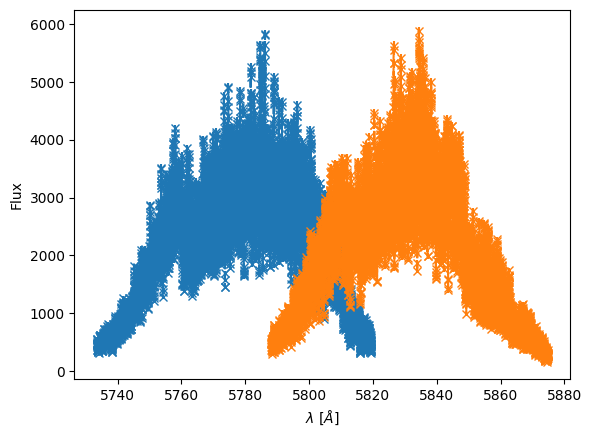

In [33]:
import matplotlib.pyplot as plt 

for order_index, wave_order in enumerate(wavelength):
    if (not 110 < order_index < 115) or order_index %2 != 0:
        continue
    plt.errorbar(wave_order, 
                 fluxes[order_index],
                 yerr=uncertainties[order_index], 
                 marker="x",
                 ls="--"
                 )
    
plt.xlabel(r"$\lambda\ [\AA]$")
plt.ylabel("Flux")